# ERCP MaxViT Pipeline

Dataset root: `training/dataset`  
Classes: `Biliary_Leaks`, `Lithiasis`, `Stricture`, `Normal`

This notebook provides a reusable Torch-compatible baseline with:
- configurable, modular preprocessing and augmentation pipelines
- class-imbalance strategy switching
- evaluation on all validation samples (DenseNet-style metrics)
- Grad-CAM visualization artifact generation


In [59]:
from __future__ import annotations
from dataclasses import dataclass
from enum import Enum
from pathlib import Path
from typing import Callable, Dict, List, Tuple

import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import maxvit_t, MaxVit_T_Weights
from PIL import Image
from tqdm.auto import tqdm
from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns


## Configuration
Define dataset paths, class labels, and run modes.


In [60]:
DATASET_ROOT = Path('dataset')
ARTIFACT_DIR = Path('models/maxvit/baseline-preprocessing-augmentation-image-size-448')
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'maxvit_tiny'

CLASSES = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}
IDX_TO_CLASS = {i: c for c, i in CLASS_TO_IDX.items()}

class ImbalanceMode(str, Enum):
    NORMAL = 'normal'
    WEIGHTED_LOSS = 'weighted_loss'
    UNIFORM_SAMPLING = 'uniform_sampling'


## Pipeline Configuration
Set modular preprocessing, augmentation, and run-time configuration objects.


In [61]:
@dataclass
class PreprocessStep:
    name: str
    enabled: bool = True

@dataclass
class AugmentStep:
    name: str
    enabled: bool = True
    prob: float = 1.0

@dataclass
class PreprocessConfig:
    resize: Tuple[int, int] = (512, 512)
    clahe_clip_limit: float = 2.0
    clahe_tile_grid: Tuple[int, int] = (8, 8)
    steps: Tuple[PreprocessStep, ...] = (
        PreprocessStep('clahe', enabled=True),
        PreprocessStep('resize', enabled=True),
    )

@dataclass
class AugmentConfig:
    rotation_deg: float = 40.0
    zoom_factor: float = 1.2
    brightness_delta: float = 0.2
    blur_kernel: int = 3
    preserve_border: bool = True
    steps: Tuple[AugmentStep, ...] = (
        AugmentStep('brightness', enabled=True, prob=0.7),
        AugmentStep('blur', enabled=True, prob=0.4),
        AugmentStep('rotation', enabled=True, prob=0.7),
        AugmentStep('zoom', enabled=True, prob=0.6),
    )

@dataclass
class RunConfig:
    imbalance_mode: ImbalanceMode = ImbalanceMode.NORMAL
    batch_size: int = 8
    num_workers: int = 0
    lr: float = 1e-3
    epochs: int = 80
    use_gradcam: bool = True


In [62]:
PREPROCESS_REGISTRY: Dict[str, Callable[[np.ndarray, PreprocessConfig], np.ndarray]] = {}

def register_preprocess(name: str):
    def deco(fn):
        PREPROCESS_REGISTRY[name] = fn
        return fn
    return deco

@register_preprocess('clahe')
def preprocess_clahe(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=cfg.clahe_clip_limit, tileGridSize=cfg.clahe_tile_grid)
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

@register_preprocess('resize')
def preprocess_resize(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    return cv2.resize(img_bgr, cfg.resize, interpolation=cv2.INTER_AREA)

def apply_preprocessing_pipeline(img_bgr: np.ndarray, cfg: PreprocessConfig) -> np.ndarray:
    out = img_bgr
    for step in cfg.steps:
        if not step.enabled:
            continue
        fn = PREPROCESS_REGISTRY.get(step.name)
        if fn is None:
            raise ValueError(f'Unknown preprocessing step: {step.name}')
        out = fn(out, cfg)
    return out


## Image Preprocessing and Augmentation
Register reusable preprocessing steps and augmentation operations.


In [63]:
def detect_content_bbox(img_bgr: np.ndarray, threshold: int = 8):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    ys, xs = np.where(gray > threshold)
    if len(xs) == 0 or len(ys) == 0:
        return 0, 0, img_bgr.shape[1], img_bgr.shape[0]
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    return x0, y0, x1, y1

def border_preserving_zoom(img_bgr: np.ndarray, zoom_factor: float) -> np.ndarray:
    if zoom_factor <= 1.0:
        return img_bgr

    # Determine content bbox and work on the ROI
    h, w = img_bgr.shape[:2]
    x0, y0, x1, y1 = detect_content_bbox(img_bgr)
    roi = img_bgr[y0:y1+1, x0:x1+1]
    rh, rw = roi.shape[:2]

    # Create a mask of 'content' pixels (non-dark). We'll preserve dark border pixels.
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_roi = gray[y0:y1+1, x0:x1+1]
    mask = gray_roi > 8  # keep same threshold as detect_content_bbox default

    # Compute a central crop of the ROI, upscale it back to ROI size
    zh, zw = max(1, int(rh / zoom_factor)), max(1, int(rw / zoom_factor))
    cy, cx = rh // 2, rw // 2
    sy, sx = max(0, cy - zh // 2), max(0, cx - zw // 2)
    crop = roi[sy:sy+zh, sx:sx+zw]
    zoomed = cv2.resize(crop, (rw, rh), interpolation=cv2.INTER_LINEAR)

    # Blend: only replace pixels where mask==True (content) AND zoomed pixel is not near-black
    out = img_bgr.copy()
    if mask.any():
        # compute where zoomed image actually has content (avoid copying black corners from rotation)
        zoomed_gray = cv2.cvtColor(zoomed, cv2.COLOR_BGR2GRAY)
        zoom_mask = zoomed_gray > 8
        final_mask = mask & zoom_mask
        if final_mask.any():
            mask3 = np.repeat(final_mask[:, :, None], 3, axis=2)
            roi_out = out[y0:y1+1, x0:x1+1]
            roi_out[mask3] = zoomed[mask3]
            out[y0:y1+1, x0:x1+1] = roi_out

    return out

def augment_brightness(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    alpha = 1.0 + np.random.uniform(-cfg.brightness_delta, cfg.brightness_delta)
    return cv2.convertScaleAbs(img_bgr, alpha=alpha, beta=0)

def augment_blur(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    k = max(1, int(cfg.blur_kernel))
    if k % 2 == 0:
        k += 1
    return cv2.GaussianBlur(img_bgr, (k, k), 0)

def augment_rotation(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    ang = np.random.uniform(-cfg.rotation_deg, cfg.rotation_deg)
    h, w = img_bgr.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), ang, 1.0)
    return cv2.warpAffine(img_bgr, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0, 0, 0))

def augment_zoom(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    if cfg.preserve_border:
        return border_preserving_zoom(img_bgr, cfg.zoom_factor)
    return img_bgr

AUGMENT_REGISTRY: Dict[str, Callable[[np.ndarray, AugmentConfig], np.ndarray]] = {
    'brightness': augment_brightness,
    'blur': augment_blur,
    'rotation': augment_rotation,
    'zoom': augment_zoom,
}

def apply_augmentation_pipeline(img_bgr: np.ndarray, cfg: AugmentConfig) -> np.ndarray:
    out = img_bgr.copy()
    for step in cfg.steps:
        if not step.enabled:
            continue
        if np.random.rand() > float(step.prob):
            continue
        fn = AUGMENT_REGISTRY.get(step.name)
        if fn is None:
            raise ValueError(f'Unknown augmentation step: {step.name}')
        out = fn(out, cfg)
    return out


In [64]:
def ensure_three_channel(img_bgr: np.ndarray) -> np.ndarray:
    if img_bgr.ndim == 2:
        return np.repeat(img_bgr[:, :, None], 3, axis=2)
    if img_bgr.ndim == 3 and img_bgr.shape[-1] == 1:
        return np.repeat(img_bgr, 3, axis=2)
    if img_bgr.ndim == 3 and img_bgr.shape[-1] == 4:
        return img_bgr[:, :, :3]
    return img_bgr


def image_to_tensor(img_bgr: np.ndarray) -> torch.Tensor:
    img_bgr = ensure_three_channel(np.ascontiguousarray(img_bgr))
    return torch.from_numpy(img_bgr.transpose(2, 0, 1)).float().div(255.0)


def load_and_transform_image(image_path: str, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None, train: bool):
    img_bgr = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if img_bgr is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')
    img_bgr = ensure_three_channel(img_bgr)
    img_bgr = apply_preprocessing_pipeline(img_bgr, pre_cfg)
    if train and aug_cfg is not None:
        img_bgr = apply_augmentation_pipeline(img_bgr, aug_cfg)
    return image_to_tensor(img_bgr)


In [65]:
def collect_split_samples(split: str) -> List[Tuple[Path, int]]:
    split_dir = DATASET_ROOT / split
    if not split_dir.exists():
        return []
    samples: List[Tuple[Path, int]] = []
    for cname in CLASSES:
        cdir = split_dir / cname
        if not cdir.exists():
            continue
        for p in cdir.glob('*.png'):
            samples.append((p, CLASS_TO_IDX[cname]))
    return samples

train_samples = collect_split_samples('train')
val_samples = collect_split_samples('val')  # strict protocol; may be empty
test_samples = collect_split_samples('test')
print('train/val/test:', len(train_samples), len(val_samples), len(test_samples))


train/val/test: 1067 234 267


In [66]:
class ERCPDataset(Dataset):
    def __init__(self, samples, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None = None, train: bool = False):
        self.samples = samples
        self.pre_cfg = pre_cfg
        self.aug_cfg = aug_cfg
        self.train = train

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image_path = str(path)
        x = load_and_transform_image(image_path, self.pre_cfg, self.aug_cfg, self.train)
        return x, torch.tensor(label, dtype=torch.long), image_path


## Model Definition
Define the baseline mock model architecture.


In [67]:
class MockModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        f = self.features(x).flatten(1)
        return self.classifier(f)

class MaxViTModel(nn.Module):
    def __init__(self, num_classes=4, input_size=(448, 448)):
        super().__init__()
        if input_size[0] % 224 != 0 or input_size[1] % 224 != 0:
            raise ValueError(f"Input size {input_size} is not a multiple of 224.")
        if input_size == (224, 224):
            weights = MaxVit_T_Weights.DEFAULT
        else:
            weights = None
        self.model = maxvit_t(weights=weights, input_size=input_size)

        #Replace the final classifier layer to match our number of classes
        in_features = self.model.classifier[-1].in_features
        self.model.classifier[-1] = nn.Linear(in_features, num_classes) # type: ignore

    def load_pretrained_weights(self, checkpoint_path: Path, device: torch.device):
        if not checkpoint_path.exists():
            raise FileNotFoundError(f'Checkpoint not found: {checkpoint_path}')
        state_dict = torch.load(checkpoint_path, map_location=device)
        self.model.load_state_dict(state_dict)

    def forward(self, x):
        return self.model(x)

## Data Loaders and Imbalance Strategy
Build train loader and imbalance-aware sampling or loss behavior.


In [68]:
def build_train_loader(samples, pre_cfg, aug_cfg, run_cfg):
    ds = ERCPDataset(samples, pre_cfg, aug_cfg=aug_cfg, train=True)
    if run_cfg.imbalance_mode == ImbalanceMode.UNIFORM_SAMPLING:
        labels = np.array([y for _, y in samples])
        counts = np.bincount(labels, minlength=len(CLASSES)) + 1e-6
        w = 1.0 / counts
        sw = np.array([w[y] for y in labels], dtype=np.float32)
        sampler = WeightedRandomSampler(sw, num_samples=len(sw), replacement=True)
        return DataLoader(ds, batch_size=run_cfg.batch_size, sampler=sampler, num_workers=run_cfg.num_workers)
    return DataLoader(ds, batch_size=run_cfg.batch_size, shuffle=True, num_workers=run_cfg.num_workers)

def class_weights_from_samples(samples):
    labels = np.array([y for _, y in samples])
    counts = np.bincount(labels, minlength=len(CLASSES)) + 1e-6
    w = counts.sum() / counts
    return torch.tensor(w, dtype=torch.float32)


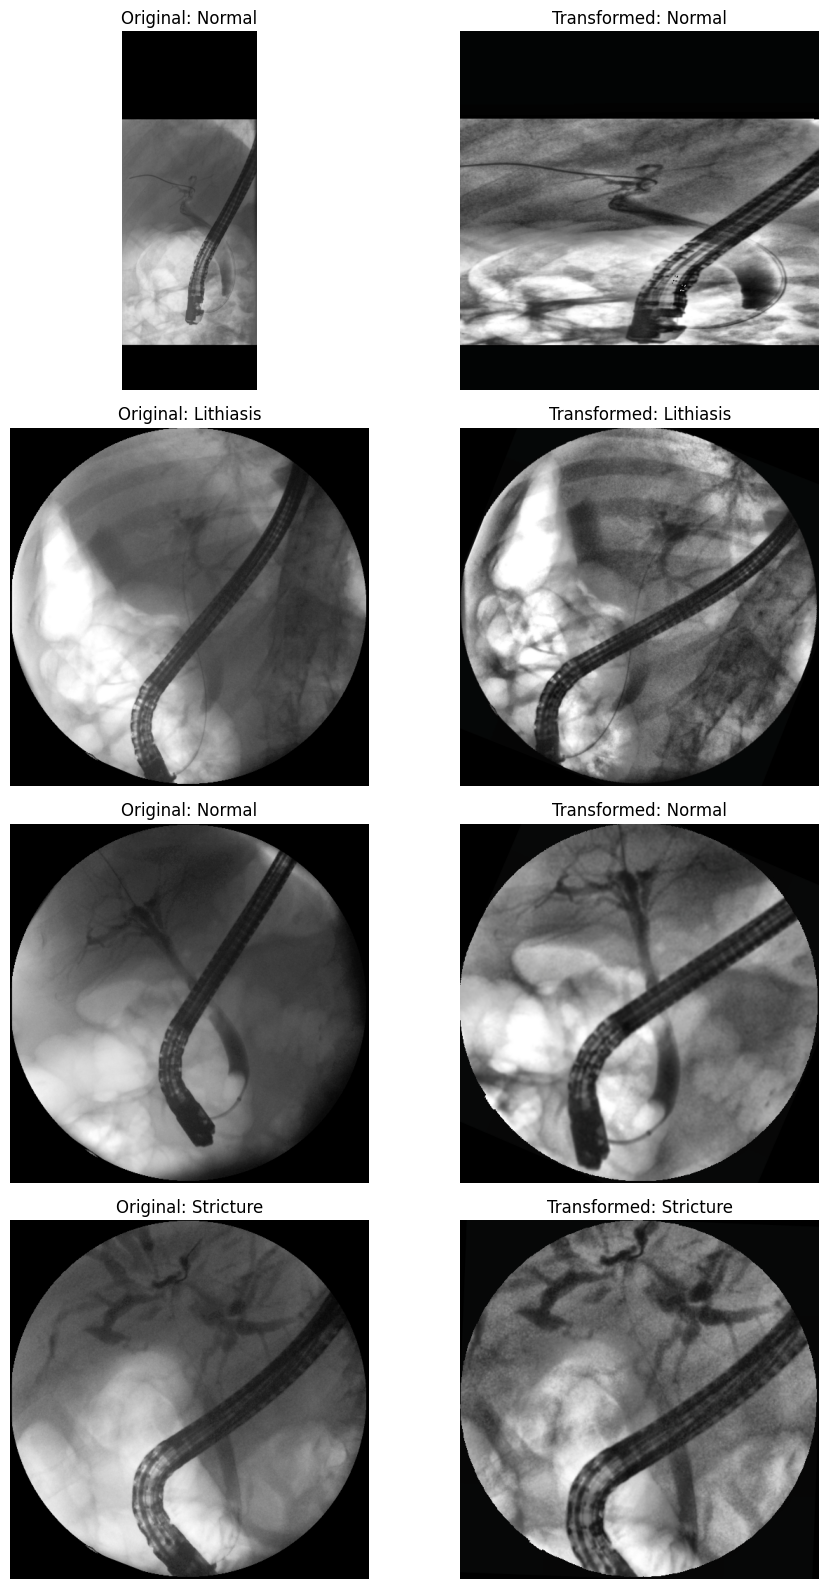

In [69]:
def show_pre_post_transform_examples(samples, pre_cfg: PreprocessConfig, aug_cfg: AugmentConfig | None, n_examples: int = 4):
    if not samples:
        print('No samples available for preview.')
        return

    preview_count = min(int(n_examples), len(samples))
    preview_ds = ERCPDataset(samples, pre_cfg, aug_cfg=aug_cfg, train=True)
    indices = np.random.choice(len(samples), size=preview_count, replace=False)
    fig, axes = plt.subplots(preview_count, 2, figsize=(10, 4 * preview_count))
    if preview_count == 1:
        axes = np.array([axes])

    for row, idx in enumerate(indices):
        path, label = samples[idx]
        raw = cv2.imread(str(path))
        if raw is None:
            raw = np.zeros((pre_cfg.resize[1], pre_cfg.resize[0], 3), dtype=np.uint8)
        else:
            raw = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)

        transformed, _, _ = preview_ds[idx]
        transformed = transformed.detach().cpu()
        if transformed.ndim == 3:
            transformed = transformed.permute(1, 2, 0).numpy()[..., ::-1]
        transformed = transformed.astype(np.float32)
        transformed -= transformed.min()
        if transformed.max() > 0:
            transformed /= transformed.max()

        axes[row, 0].imshow(raw)
        axes[row, 0].set_title(f'Original: {CLASSES[label]}')
        axes[row, 0].axis('off')
        axes[row, 1].imshow(transformed)
        axes[row, 1].set_title(f'Transformed: {CLASSES[label]}')
        axes[row, 1].axis('off')

    plt.tight_layout()
    plt.show()


preview_pre_cfg = PreprocessConfig(clahe_clip_limit=4.0, clahe_tile_grid=(8, 8), steps=(
    PreprocessStep('clahe', enabled=True),
    PreprocessStep('resize', enabled=True),
))
preview_aug_cfg = AugmentConfig()
if train_samples:
    show_pre_post_transform_examples(train_samples, preview_pre_cfg, preview_aug_cfg, n_examples=4)


## Model Training and Evaluation
Train the model and evaluate on all validation samples with metrics and confusion matrix.


In [70]:
def evaluate_model(data_loader: DataLoader, model: nn.Module, device: str):
    predictions = []
    actual_values = []
    probs_list = []
    model.eval()

    with torch.no_grad():
        for inputs, labels, _ in tqdm(data_loader, total=len(data_loader), desc='Evaluating', leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = np.argmax(probs, axis=1)
            actual = labels.cpu().numpy()

            probs_list.append(probs)
            predictions.append(preds.reshape((-1, 1)))
            actual_values.append(actual.reshape((-1, 1)))

    if not predictions:
        return np.array([]), np.array([]), np.array([])

    predictions = np.vstack(predictions)
    actual_values = np.vstack(actual_values)
    probs_all = np.vstack(probs_list)

    f1 = f1_score(actual_values, predictions, average='macro', zero_division=0)
    acc = accuracy_score(actual_values, predictions)
    print(f'Validation Accuracy: {acc:0.4f}')
    print(f'Validation F1 (macro): {f1:0.4f}')
    return actual_values, predictions, probs_all



def display_confusion_matrix(cm, list_classes, filename):
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        cm,
        annot=True,
        xticklabels=list_classes,
        yticklabels=list_classes,
        annot_kws={'size': 10},
        fmt='g',
        linewidths=.5,
    )
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()


class Trainer:
    def __init__(self, train_samples, val_samples):
        self.train_samples = train_samples
        self.val_samples = val_samples

    def train(self, model: nn.Module, optimizer, num_iterations: int | None, epochs: int | None,
              save_dir: Path, model_name: str, preprocess_config: PreprocessConfig,
              augmentation_config: AugmentConfig, run_config: RunConfig):
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model = model.to(device)
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)

        train_loader = build_train_loader(self.train_samples, preprocess_config, augmentation_config, run_config)
        val_loader = None
        if self.val_samples:
            val_loader = DataLoader(
                ERCPDataset(self.val_samples, preprocess_config, train=False),
                batch_size=run_config.batch_size,
                shuffle=False,
                num_workers=run_config.num_workers,
            )

        cw = class_weights_from_samples(self.train_samples).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw if run_config.imbalance_mode == ImbalanceMode.WEIGHTED_LOSS else None)
        print(epochs, num_iterations)
        total_epochs = int(epochs if epochs is not None else max(1, int(num_iterations or 1)))
        plot_path = ARTIFACT_DIR / f'{Path(model_name).stem}_training_curve.png'
        liveloss = PlotLosses(outputs=[MatplotlibPlot(figpath=str(plot_path))])
        best_metric = -1.0
        best_metric_epoch = -1
        best_train_f1 = 0.0
        epochs_without_improvement = 0

        last_val_true = None
        last_val_probs = None
        last_val_binary_roc = 0.0

        def evaluate_epoch(loader):
            model.eval()
            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_targets = []
            all_probs = []

            with torch.no_grad():
                for inputs, labels, _ in loader:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    logits = model(inputs)
                    loss = criterion(logits, labels)
                    running_loss += loss.item() * inputs.size(0)
                    probs = torch.softmax(logits, dim=1)
                    preds = probs.argmax(dim=1)
                    running_corrects += (preds == labels).sum().item()
                    all_probs.append(probs.detach().cpu())
                    all_preds.append(preds.detach().cpu())
                    all_targets.append(labels.detach().cpu())

            if not all_preds:
                return 0.0, 0.0, 0.0, 0.0, np.array([]), np.array([]), 0.0

            y_pred = torch.cat(all_preds).numpy()
            y_true = torch.cat(all_targets).numpy()
            y_probs = torch.cat(all_probs).numpy()
            avg_loss = running_loss / len(loader.dataset)
            avg_acc = running_corrects / len(loader.dataset)
            avg_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

            # multiclass ROC-AUC
            try:
                n_classes = y_probs.shape[1]
                if n_classes == 2:
                    avg_roc = roc_auc_score(y_true, y_probs[:, 1])
                else:
                    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
                    avg_roc = roc_auc_score(y_true_bin, y_probs, average='macro', multi_class='ovr')
            except Exception:
                avg_roc = 0.0

            # binary ROC (Normal vs Disease)
            try:
                normal_idx = CLASS_TO_IDX.get('Normal', None)
                if normal_idx is not None:
                    y_binary = (y_true != normal_idx).astype(int)
                    disease_mask = [i for i in range(y_probs.shape[1]) if i != normal_idx]
                    disease_prob = y_probs[:, disease_mask].sum(axis=1)
                    binary_roc = roc_auc_score(y_binary, disease_prob)
                else:
                    binary_roc = 0.0
            except Exception:
                binary_roc = 0.0

            return avg_loss, avg_acc, avg_f1, float(avg_roc), y_true, y_probs, float(binary_roc)

        for epoch in range(total_epochs):
            model.train()
            train_running_loss = 0.0
            train_running_corrects = 0
            train_preds = []
            train_targets = []
            train_bar = tqdm(train_loader, total=len(train_loader), desc=f'Training epoch {epoch + 1}/{total_epochs}', leave=False)

            for x, y, _ in train_bar:
                x, y = x.to(device), y.to(device)
                optimizer.zero_grad()
                logits = model(x)
                loss = criterion(logits, y)
                loss.backward()
                optimizer.step()

                train_running_loss += loss.item() * x.size(0)
                preds = logits.argmax(dim=1)
                train_running_corrects += (preds == y).sum().item()
                train_preds.append(preds.detach().cpu())
                train_targets.append(y.detach().cpu())
                train_bar.set_postfix(loss=f'{loss.item():.4f}')

            train_loss = train_running_loss / len(train_loader.dataset)
            train_acc = train_running_corrects / len(train_loader.dataset)
            train_f1 = f1_score(torch.cat(train_targets).numpy(), torch.cat(train_preds).numpy(), average='macro', zero_division=0)

            val_loss = 0.0
            val_acc = 0.0
            val_f1 = 0.0
            val_roc = 0.0
            val_binary_roc = 0.0
            y_val_true = np.array([])
            y_val_probs = np.array([])
            if val_loader is not None:
                val_loss, val_acc, val_f1, val_roc, y_val_true, y_val_probs, val_binary_roc = evaluate_epoch(val_loader)
                # keep last validation probs for final-epoch ROC saving
                last_val_true = y_val_true
                last_val_probs = y_val_probs
                last_val_binary_roc = val_binary_roc

            logs = {
                'loss': train_loss,
                'accuracy': train_acc,
                'val_loss': val_loss,
                'val_accuracy': val_acc,
                'val_F1': val_f1,
                'val_roc_auc': val_roc,
                'val_roc_auc_binary': val_binary_roc,
            }
            liveloss.update(logs)
            liveloss.send()

            current_metric = val_f1 if val_loader is not None else train_f1
            if current_metric > best_metric:
                best_metric = current_metric
                best_metric_epoch = epoch + 1
                best_train_f1 = train_f1
                torch.save(model.state_dict(), save_dir / (model_name + '.pth'))

                print('saved new best metric model')
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if val_loader is not None and epochs_without_improvement >= 100:
                print(
                    f'Early stopping at epoch {epoch + 1} \n'
                    f' Best Val F1: {best_metric:.4f} \n'
                    f' Best Train F1: {best_train_f1:.4f} \n'
                    f' current Val F1: {val_f1:.4f} \n'
                    f' current Train F1: {train_f1:.4f} \n'
                    f' Best epoch: {best_metric_epoch} \n',
                )
                break

            print(
                f'current epoch: {epoch + 1} current Train F1: {train_f1:.4f}'
                f' current Val F1: {val_f1:.4f}'
                f' best metric: {best_metric:.4f}'
                f' at epoch: {best_metric_epoch}'
            )

        # After training: save ROC plot only for final epoch (if available)
        try:
            if last_val_true is not None and last_val_probs is not None and last_val_true.size and last_val_probs.size:
                normal_idx = CLASS_TO_IDX.get('Normal', None)
                if normal_idx is not None:
                    disease_mask = [i for i in range(last_val_probs.shape[1]) if i != normal_idx]
                    disease_prob = last_val_probs[:, disease_mask].sum(axis=1)
                    fpr, tpr, _ = roc_curve((last_val_true != normal_idx).astype(int), disease_prob)
                    plt.figure()
                    plt.plot(fpr, tpr, label=f'ROC (binary) AUC={last_val_binary_roc:.3f}')
                    plt.plot([0, 1], [0, 1], '--', color='gray')
                    plt.xlabel('False Positive Rate')
                    plt.ylabel('True Positive Rate')
                    plt.title(f'ROC Curve Final Epoch')
                    plt.legend(loc='lower right')
                    roc_path = ARTIFACT_DIR / f'roc_final_epoch.png'
                    plt.savefig(roc_path, dpi=150)
                    plt.close()
        except Exception:
            pass

        print(f'train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}')
        return model

    def evaluate(self, trained_model: nn.Module, eval_loader: DataLoader, run_config: RunConfig, model_name: str):
        device = next(trained_model.parameters()).device
        actual_values, predictions, probs = evaluate_model(eval_loader, trained_model, device.type)

        metrics = {
            'per_class': {c: 0.0 for c in CLASSES},
            'aggregate': {'accuracy': 0.0, 'f1_macro': 0.0},
            'artifacts': {'confusion_matrix': None, 'classification_report': None},
        }

        if actual_values.size > 0:
            report_text = classification_report(
                actual_values,
                predictions,
                labels=list(range(len(CLASSES))),
                target_names=CLASSES,
                digits=4,
                zero_division=0,
            )
            cm = confusion_matrix(actual_values, predictions)

            acc = accuracy_score(actual_values, predictions)
            f1 = f1_score(actual_values, predictions, average='macro', zero_division=0)
            metrics['aggregate']['accuracy'] = float(acc)
            metrics['aggregate']['f1_macro'] = float(f1)

            for i, c in enumerate(CLASSES):
                cls_mask = (actual_values.flatten() == i)
                denom = max(1, int(cls_mask.sum()))
                metrics['per_class'][c] = float((predictions.flatten()[cls_mask] == i).sum() / denom)

            # Compute ROC-AUC from returned probabilities when available
            try:
                if probs.size > 0:
                    n_classes = probs.shape[1]
                    if n_classes == 2:
                        roc = roc_auc_score(actual_values, probs[:, 1])
                    else:
                        y_true_bin = label_binarize(actual_values.flatten(), classes=list(range(n_classes)))
                        roc = roc_auc_score(y_true_bin, probs, average='macro', multi_class='ovr')
                    metrics['aggregate']['roc_auc'] = float(roc)
                else:
                    metrics['aggregate']['roc_auc'] = 0.0
            except Exception:
                metrics['aggregate']['roc_auc'] = 0.0

            # binary ROC (Normal vs Disease)
            try:
                normal_idx = CLASS_TO_IDX.get('Normal', None)
                if normal_idx is not None and probs.size > 0:
                    y_binary = (actual_values.flatten() != normal_idx).astype(int)
                    disease_mask = [i for i in range(probs.shape[1]) if i != normal_idx]
                    disease_prob = probs[:, disease_mask].sum(axis=1)
                    roc_bin = roc_auc_score(y_binary, disease_prob)
                    metrics['aggregate']['roc_auc_binary'] = float(roc_bin)
                else:
                    metrics['aggregate']['roc_auc_binary'] = 0.0
            except Exception:
                metrics['aggregate']['roc_auc_binary'] = 0.0

            cm_path = ARTIFACT_DIR / f'{model_name}_cm.png'
            report_path = ARTIFACT_DIR / f'{model_name}_report.txt'

            display_confusion_matrix(cm, CLASSES, str(cm_path))
            print('Classification Report:')
            print(report_text)

            report_lines = [
                'ERCP Validation Evaluation Report',
                '=' * 36,
                f"Accuracy: {metrics['aggregate']['accuracy']:.4f}",
                f"F1 Macro: {metrics['aggregate']['f1_macro']:.4f}",
                f"ROC AUC (multiclass): {metrics['aggregate'].get('roc_auc', 0.0):.4f}",
                f"ROC AUC (binary Normal vs Disease): {metrics['aggregate'].get('roc_auc_binary', 0.0):.4f}",
                '',
                'Per-class Accuracy:',
            ]
            report_lines.extend([f"- {k}: {v:.4f}" for k, v in metrics['per_class'].items()])
            report_lines.extend([
                '',
                'Classification Report:',
                str(report_text),
                '',
                'Confusion Matrix:',
                str(np.array2string(cm)),
                '',
            ])
            report_path.write_text(''.join(report_lines))

            metrics['artifacts']['confusion_matrix'] = str(cm_path)
            metrics['artifacts']['classification_report'] = str(report_path)

        return metrics


## Grad-CAM Visualization
Generate class-activation maps to inspect model attention regions.


In [71]:
def gradcam_overlay(model: nn.Module, x: torch.Tensor, target_class: int):
    model.eval()
    device = next(model.parameters()).device
    feats, grads = {}, {}

    # Use the last Conv2d in the model so this works for both CNN and MaxViT wrappers.
    target_layer = None
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            target_layer = module
    if target_layer is None:
        raise ValueError('No Conv2d layer found for Grad-CAM.')

    def fw_hook(_, __, out):
        feats['v'] = out

    def bw_hook(_, gin, gout):
        grads['v'] = gout[0]

    h1 = target_layer.register_forward_hook(fw_hook)
    h2 = target_layer.register_full_backward_hook(bw_hook)

    x = x.unsqueeze(0).to(device)
    logits = model(x)
    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    fmap = feats['v'][0]
    grad = grads['v'][0]
    w = grad.mean(dim=(1,2), keepdim=True)
    cam = (w * fmap).sum(0).detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    h1.remove(); h2.remove()
    return cam


## Baseline Run
Execute an end-to-end training, evaluation, and Grad-CAM outputs.


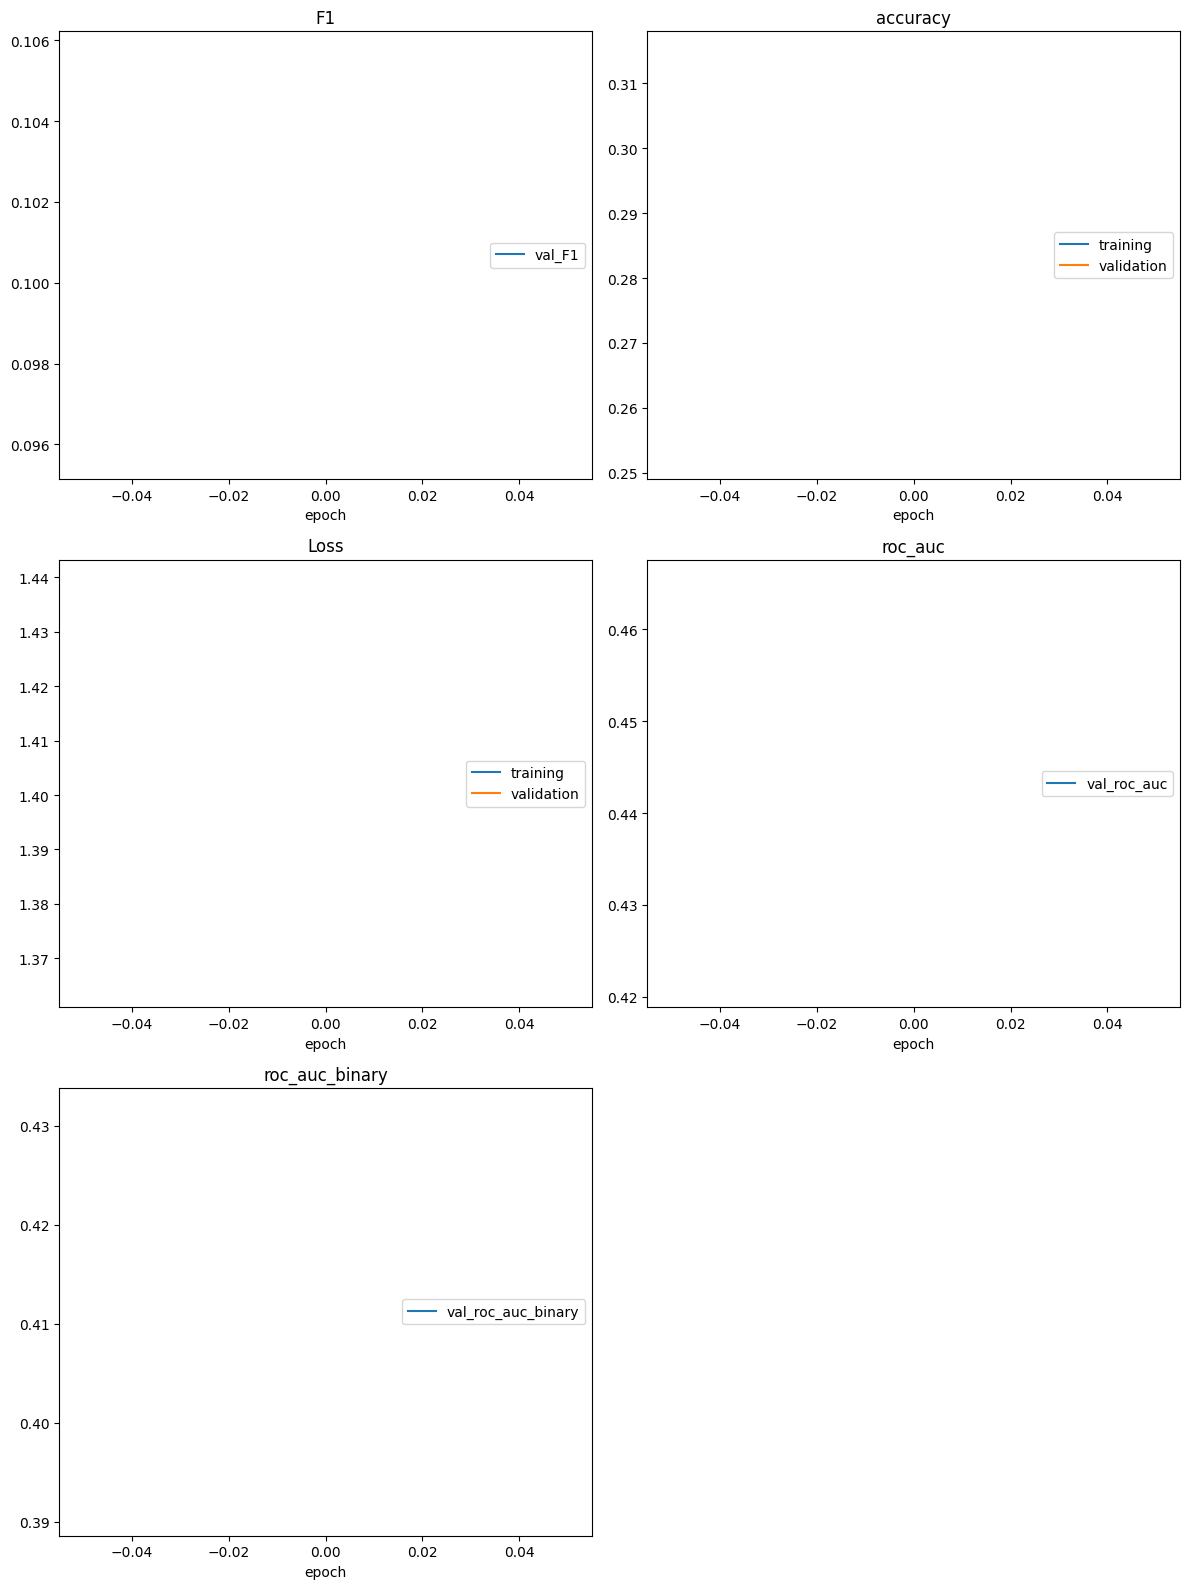

saved new best metric model
current epoch: 1 current Train F1: 0.2612 current Val F1: 0.1007 best metric: 0.1007 at epoch: 1


Training epoch 2/400:   0%|          | 0/178 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [72]:
# Smoke run
pre_cfg = PreprocessConfig(resize=(448, 448),steps=(
    PreprocessStep('clahe', enabled=True),
    PreprocessStep('resize', enabled=True),
))
aug_cfg = AugmentConfig(
    rotation_deg=30.0,
    zoom_factor=1.1,
    brightness_delta=0.1,
    blur_kernel=3,
    preserve_border=True,
    steps=(
        AugmentStep('brightness', enabled=True, prob=0.5),
        AugmentStep('blur', enabled=True, prob=0.3),
        AugmentStep('rotation', enabled=True, prob=0.5),
        AugmentStep('zoom', enabled=True, prob=0.4),
    )
)
run_cfg = RunConfig(imbalance_mode=ImbalanceMode.WEIGHTED_LOSS, batch_size=6, lr=6e-5, epochs=400)

# Proceed only when both train and val splits are available.
if len(train_samples) > 0 and len(val_samples) > 0:
    model = MaxViTModel(num_classes=len(CLASSES), input_size=pre_cfg.resize)
    optimizer = torch.optim.Adam(model.parameters(), lr=run_cfg.lr, weight_decay=1e-4)
    trainer = Trainer(train_samples=train_samples, val_samples=val_samples)

    trained_model = trainer.train(
        model=model,
        optimizer=optimizer,
        num_iterations=None,
        epochs=run_cfg.epochs,
        save_dir=ARTIFACT_DIR,
        model_name=MODEL_NAME,
        preprocess_config=pre_cfg,
        augmentation_config=aug_cfg,
        run_config=run_cfg,
    )

    test_loader = DataLoader(ERCPDataset(test_samples, pre_cfg, train=False), batch_size=run_cfg.batch_size, shuffle=False)
    metrics = trainer.evaluate(trained_model=trained_model, eval_loader=test_loader, run_config=run_cfg, model_name=MODEL_NAME)
    print('Per-class validation metrics:', metrics['per_class'])
    print('Aggregate metrics:', metrics['aggregate'])

    # Generate one Grad-CAM artifact from validation samples.
    if run_cfg.use_gradcam and len(test_samples) > 0:
        ds = ERCPDataset(test_samples, pre_cfg, train=False)
        x, y, p = ds[0]
        cam = gradcam_overlay(trained_model, x, int(y))
        np.save(ARTIFACT_DIR / 'gradcam_sample.npy', cam)
        print('Saved Grad-CAM:', ARTIFACT_DIR / 'gradcam_sample.npy', 'for', p)
else:
    print('Skipped smoke run: train and/or val split is empty.')